# SeqOptPlot.mutation_map — which mutations the search converged on\n\nA heatmap of substitution enrichment across the Pareto front: each cell counts how often a target amino acid is chosen at a TMD position among the optimized variants — the directed-evolution view of the designed 'super substrate' motif.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import aaanalysis as aa
aa.options["verbose"] = False
df_feat = aa.load_features(name="DOM_GSEC")
df_seq  = aa.load_dataset(name="DOM_GSEC", n=50)
labels  = df_seq["label"].to_list()
sf = aa.SequenceFeature()
X = np.asarray(sf.feature_matrix(features=df_feat["feature"],
                                 df_parts=sf.get_df_parts(df_seq=df_seq),
                                 df_scales=aa.load_scales()), dtype=float)
model = RandomForestClassifier(n_estimators=100, random_state=0).fit(X, labels)
wt = df_seq[df_seq["label"] == 0].iloc[[0]].reset_index(drop=True)
objectives = [("substrate", "max", "delta_pred"), ("parsimony", "min", "n_mut")]
seqopt = aa.SeqOpt(mode="importance", model=model, target_class=1, random_state=42)
df_pareto = seqopt.run(df_seq=wt, df_feat=df_feat, objectives=objectives,
                       pop_size=40, n_gen=20, n_mut_max=5, region="tmd")
aa.display_df(df_pareto, n_rows=10, show_shape=True)


/Users/stephanbreimann/Programming/1Packages/wt-seqopt-deap/aaanalysis/feature_engineering/_backend/cpp_run.py:163: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


DataFrame shape: (7, 8)


,entry,variant,n_mut,sequence_mut,substrate,parsimony,rank,crowding
1,Q14802,,0,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0.000000,0.000000,0,inf
2,Q14802,L37T+I55T+V56L+S58Q+A59R,5,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,37.000000,5.000000,0,inf
3,Q14802,L37G+A59R,2,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,29.000000,2.000000,0,0.429730
4,Q14802,A59R,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,16.000000,1.000000,0,0.316216
5,Q14802,L37G+V56L+A59R,3,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,33.000000,3.000000,0,0.281081
6,Q14802,A59K,1,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,16.000000,1.000000,0,0.275676
7,Q14802,L37G+V56L+S58Q+A59R,4,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,35.000000,4.000000,0,0.254054


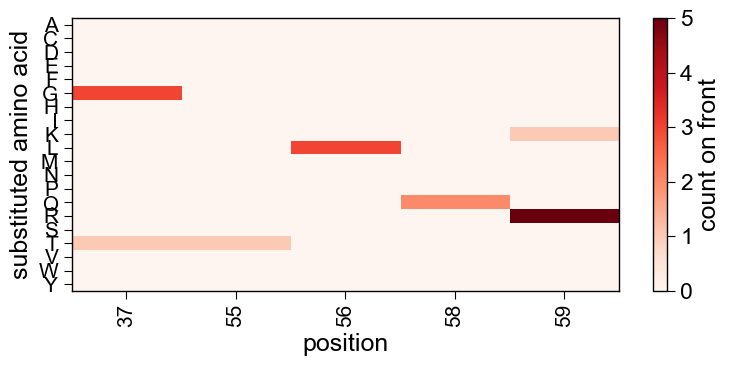

In [2]:
aa.plot_settings()
aa.SeqOptPlot().mutation_map(df_pareto=df_pareto, front_only=True)
plt.tight_layout(); plt.show()